# Advanced Self-Attention (PyTorch) - End-to-End Pipeline
**Date**: 2026-05-31  
**Objective**: Benchmark dense, sparse, linear, and grouped-query attention with PyTorch and shared preprocessing.

## 1) Imports and Setup

In [1]:
from __future__ import annotations

import math
import os
import random
import sys
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = str(SEED)

def parse_use_gpu_flag(raw_value: str) -> bool:
    normalized = raw_value.strip().lower()
    return normalized not in {"0", "false", "no", "off"}

def load_runtime_env() -> None:
    env_files = [Path("configs/runtime.env"), Path("configs/runtime.env.example"), Path("../configs/runtime.env"), Path("../configs/runtime.env.example")]
    for env_file in env_files:
        if env_file.exists():
            for line in env_file.read_text(encoding="utf-8").splitlines():
                line = line.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, value = line.split("=", 1)
                os.environ.setdefault(key.strip(), value.strip().strip("\"'"))
            break

def register_local_module_path() -> None:
    candidates = [Path("."), Path("self-attention-variants"), Path("../self-attention-variants")]
    for candidate in candidates:
        if (candidate / "shared_text_preprocessing.py").exists():
            resolved = str(candidate.resolve())
            if resolved not in sys.path:
                sys.path.insert(0, resolved)
            return
    raise FileNotFoundError("Could not locate shared_text_preprocessing.py")

load_runtime_env()
register_local_module_path()
USE_GPU = parse_use_gpu_flag(os.getenv("USE_GPU", "1"))
device = torch.device("cuda" if USE_GPU and torch.cuda.is_available() else "cpu")
print(f"runtime_device={device}")

from shared_text_preprocessing import PreprocessingConfig, prepare_text_data

runtime_device=cuda


## 2) Configuration and Constants

In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    num_samples: int = 64
    seq_len: int = 128
    d_model: int = 48
    local_window: int = 8
    temperature_grid_size: int = 31


CFG = ExperimentConfig()
CFG

ExperimentConfig(num_samples=64, seq_len=128, d_model=48, local_window=8, temperature_grid_size=31)

## 3) Data Loading

In [3]:
prep_cfg = PreprocessingConfig(num_samples=CFG.num_samples, seq_len=CFG.seq_len, max_vocab_size=4096, train_ratio=0.8)
data = prepare_text_data(prep_cfg, seed=SEED)
len(data.texts_train), len(data.texts_test), data.y_train.shape, data.y_test.shape

(51, 13, (51,), (13,))

## 4) EDA

In [4]:
train_lengths = np.array([len(t.split()) for t in data.texts_train], dtype=np.int64)
train_class_counts = np.bincount(data.y_train, minlength=2)
test_class_counts = np.bincount(data.y_test, minlength=2)
print("Train class counts:", train_class_counts.tolist())
print("Test class counts:", test_class_counts.tolist())
print("Train token-length mean/std:", float(train_lengths.mean()), float(train_lengths.std()))

Train class counts: [25, 26]
Test class counts: [7, 6]
Train token-length mean/std: 8.0 0.0


## 5) Preprocessing / Feature Engineering

In [5]:
embedding = torch.nn.Embedding(len(data.vocab), CFG.d_model, device=device)
with torch.no_grad():
    embedding.weight.copy_(torch.randn(len(data.vocab), CFG.d_model, device=device) * 0.2)

x_train = embedding(torch.tensor(data.train_token_ids, dtype=torch.long, device=device))
x_test = embedding(torch.tensor(data.test_token_ids, dtype=torch.long, device=device))

def init_projection_weights(d_model: int, device: torch.device) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    w_q = torch.randn(d_model, d_model, device=device) * 0.2
    w_k = torch.randn(d_model, d_model, device=device) * 0.2
    w_v = torch.randn(d_model, d_model, device=device) * 0.2
    return w_q, w_k, w_v

def apply_qkv_projection(x: torch.Tensor, w_q: torch.Tensor, w_k: torch.Tensor, w_v: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    return x @ w_q, x @ w_k, x @ w_v

w_q, w_k, w_v = init_projection_weights(CFG.d_model, device)
q_train, k_train, v_train = apply_qkv_projection(x_train, w_q, w_k, w_v)
q_test, k_test, v_test = apply_qkv_projection(x_test, w_q, w_k, w_v)

## 6) Model Definition (Advanced Variants)

In [6]:
def dense_attention(q: torch.Tensor, k: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(q.size(-1))
    weights = torch.softmax(scores, dim=-1)
    return torch.matmul(weights, v)

def sparse_with_temperature(q: torch.Tensor, k: torch.Tensor, v: torch.Tensor, window: int, temperature: float) -> torch.Tensor:
    batch, seq_len, _ = q.shape
    scores = torch.full((batch, seq_len, seq_len), -1e9, device=q.device)
    raw = torch.matmul(q, k.transpose(-2, -1)) / (math.sqrt(q.size(-1)) * temperature)
    for i in range(seq_len):
        lo = max(0, i - window)
        hi = min(seq_len, i + window + 1)
        scores[:, i, lo:hi] = raw[:, i, lo:hi]
    weights = torch.softmax(scores, dim=-1)
    return torch.matmul(weights, v)

def linear_attention(q: torch.Tensor, k: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
    q_phi = torch.relu(q) + 1e-3
    k_phi = torch.relu(k) + 1e-3
    kv = torch.einsum("bnd,bne->bde", k_phi, v)
    z = 1.0 / (torch.einsum("bnd,bd->bn", q_phi, k_phi.sum(dim=1)) + 1e-6)
    return torch.einsum("bnd,bde,bn->bne", q_phi, kv, z)

def grouped_query_attention(q: torch.Tensor, k: torch.Tensor, v: torch.Tensor, num_groups: int = 4) -> torch.Tensor:
    batch, seq_len, d_model = q.shape
    if d_model % num_groups != 0:
        raise ValueError(f"d_model ({d_model}) must be divisible by num_groups ({num_groups}).")
    group_dim = d_model // num_groups
    qg = q.view(batch, seq_len, num_groups, group_dim).permute(0, 2, 1, 3)
    k_shared = k.view(batch, seq_len, num_groups, group_dim).mean(dim=2)
    v_shared = v.view(batch, seq_len, num_groups, group_dim).mean(dim=2)
    outputs = []
    for g in range(num_groups):
        scores = torch.matmul(qg[:, g], k_shared.transpose(-2, -1)) / math.sqrt(group_dim)
        weights = torch.softmax(scores, dim=-1)
        outputs.append(torch.matmul(weights, v_shared))
    return torch.stack(outputs, dim=1).permute(0, 2, 1, 3).reshape(batch, seq_len, d_model)

## 7) Training (Sparse Temperature Tuning)

In [7]:
teacher_train = dense_attention(q_train, k_train, v_train)
temp_grid = torch.linspace(0.5, 2.0, CFG.temperature_grid_size, device=device)
best_temp = float(temp_grid[0].item())
best_mse = float("inf")

for temp in temp_grid:
    student = sparse_with_temperature(q_train, k_train, v_train, CFG.local_window, float(temp.item()))
    mse = float(torch.mean((student - teacher_train) ** 2).item())
    if mse < best_mse:
        best_mse = mse
        best_temp = float(temp.item())

print({"best_temperature": best_temp, "train_mse": best_mse})

{'best_temperature': 2.0, 'train_mse': 0.0019613474141806364}


## 8) Evaluation and Metrics

In [8]:
def timed_run(fn, *args):
    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    out = fn(*args)
    if device.type == "cuda":
        torch.cuda.synchronize()
    return out, (time.perf_counter() - start) * 1000.0

teacher_test, t_dense = timed_run(dense_attention, q_test, k_test, v_test)
sparse_test, t_sparse = timed_run(sparse_with_temperature, q_test, k_test, v_test, CFG.local_window, best_temp)
linear_test, t_linear = timed_run(linear_attention, q_test, k_test, v_test)
gqa_test, t_gqa = timed_run(grouped_query_attention, q_test, k_test, v_test)

metrics = {
    "dense_ms": float(t_dense),
    "sparse_ms": float(t_sparse),
    "linear_ms": float(t_linear),
    "gqa_ms": float(t_gqa),
    "sparse_mse_vs_dense": float(torch.mean((sparse_test - teacher_test) ** 2).item()),
    "linear_mse_vs_dense": float(torch.mean((linear_test - teacher_test) ** 2).item()),
    "gqa_mse_vs_dense": float(torch.mean((gqa_test - teacher_test) ** 2).item()),
}
metrics

{'dense_ms': 1.0073580001517257,
 'sparse_ms': 2.3638220000066212,
 'linear_ms': 55.05502100004378,
 'gqa_ms': 8.332070000051317,
 'sparse_mse_vs_dense': 0.0020345253869891167,
 'linear_mse_vs_dense': 0.00024098630819935352,
 'gqa_mse_vs_dense': 0.03083641827106476}

## 9) Results Visualization

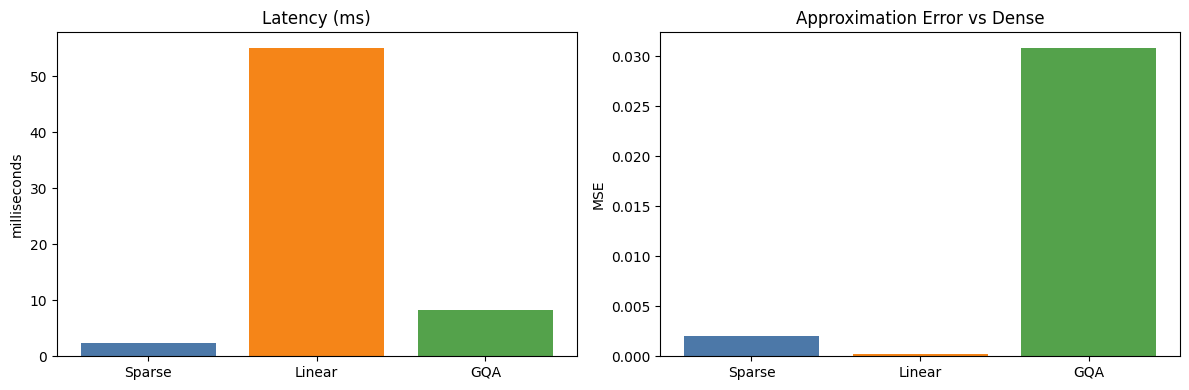

In [9]:
names = ["Sparse", "Linear", "GQA"]
latency = [metrics["sparse_ms"], metrics["linear_ms"], metrics["gqa_ms"]]
mse = [metrics["sparse_mse_vs_dense"], metrics["linear_mse_vs_dense"], metrics["gqa_mse_vs_dense"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(names, latency, color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Latency (ms)")
axes[0].set_ylabel("milliseconds")

axes[1].bar(names, mse, color=["#4C78A8", "#F58518", "#54A24B"])
axes[1].set_title("Approximation Error vs Dense")
axes[1].set_ylabel("MSE")

plt.tight_layout()
plt.show()

## 10) Summary
- Reused shared text tokenization and preprocessing helpers for consistent inputs.
- Benchmarked advanced attention variants in PyTorch on a shared QKV projection.
- Reported latency and approximation error relative to dense attention.